<a href="https://colab.research.google.com/github/Benedict-Johnson/Yolov11-Tensar/blob/main/Tensar%2BYolov11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# STEP 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# STEP 2: Unzip dataset
import zipfile
import os

zip_path = '/content/drive/My Drive/YOLOv11_Project/dataset.zip'
extract_path = '/content/coconut_dataset'

# Create folder and unzip
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset unzipped to:", extract_path)


✅ Dataset unzipped to: /content/coconut_dataset


In [ ]:
# STEP 3: Check the folders and classes
import os

for root, dirs, files in os.walk(extract_path):
    print(f"\n📁 {root}")
    for name in dirs:
        print("   📂", name)
    for name in files[:5]:  # print first 5 files only
        print("   📸", name)
    break  # only show top level



📁 /content/coconut_dataset
   📂 dataset


Train and Val Split

In [ ]:
import os
import shutil
import random

# Paths
dataset_root = "/content/coconut_dataset/dataset"
output_dir = "/content/yolo_dataset"
os.makedirs(output_dir, exist_ok=True)

# 5 class folders (should match what's inside your zip)
class_names = os.listdir(dataset_root)
class_names = [c for c in class_names if os.path.isdir(os.path.join(dataset_root, c))]
class_names.sort()
print("✅ Classes found:", class_names)

# Save for later in data.yaml
class_name_to_id = {name: idx for idx, name in enumerate(class_names)}

# Create YOLO folder structure
for split in ['train', 'val']:
    os.makedirs(os.path.join(output_dir, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'labels', split), exist_ok=True)

# Split images and create dummy labels
split_ratio = 0.8
for cls in class_names:
    cls_path = os.path.join(dataset_root, cls)
    all_images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(all_images)

    split_index = int(len(all_images) * split_ratio)
    train_imgs = all_images[:split_index]
    val_imgs = all_images[split_index:]

    for split_name, img_list in zip(['train', 'val'], [train_imgs, val_imgs]):
        for img_name in img_list:
            src_img_path = os.path.join(cls_path, img_name)
            dst_img_path = os.path.join(output_dir, 'images', split_name, f"{cls}_{img_name}")
            dst_lbl_path = os.path.join(output_dir, 'labels', split_name, f"{cls}_{img_name.rsplit('.', 1)[0]}.txt")

            # Copy image
            shutil.copy(src_img_path, dst_img_path)

            # Write dummy label (class_id center_x center_y width height) - whole image
            dummy_label = f"{class_name_to_id[cls]} 0.5 0.5 1.0 1.0\n"
            with open(dst_lbl_path, 'w') as f:
                f.write(dummy_label)

print("✅ Dataset split and YOLO-format dummy labels created!")


✅ Classes found: ['Bud_Root_Dropping', 'Bud_Rot', 'Gray_Leaf_Spot', 'Leaf_Rot', 'Stem_Bleeding']
✅ Dataset split and YOLO-format dummy labels created!


In [ ]:
# Write YOLO data.yaml
yaml_path = os.path.join(output_dir, "data.yaml")
with open(yaml_path, "w") as f:
    f.write("path: {}\n".format(output_dir))
    f.write("train: images/train\n")
    f.write("val: images/val\n")
    f.write("names: {}\n".format(class_names))

print(f"✅ data.yaml created at: {yaml_path}")


✅ data.yaml created at: /content/yolo_dataset/data.yaml


In [ ]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 77.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

In [ ]:
from ultralytics import YOLO

# Load YOLOv11n model (Nano version - fast)
model = YOLO('yolo11n.pt')

# Start training
model.train(
    data='/content/yolo_dataset/data.yaml',
    epochs=10,            # Small number to test things first
    imgsz=640,
    batch=16,
    name='yolov11_coconut_disease'
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 5.35M/5.35M [00:00<00:00, 376MB/s]

Ultralytics 8.3.169 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)


engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov11_coconut_disease, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=None, rect=False, resume=False, 

100%|██████████| 755k/755k [00:00<00:00, 108MB/s]

...

                   all       1161       1161      0.999      0.994      0.995      0.995



10 epochs completed in 0.299 hours.
Optimizer stripped from runs/detect/yolov11_coconut_disease/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/yolov11_coconut_disease/weights/best.pt, 5.5MB

Validating runs/detect/yolov11_coconut_disease/weights/best.pt...
Ultralytics 8.3.169 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,583,127 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 37/37 [00:13<00:00,  2.81it/s]


                   all       1161       1161      0.999      0.994      0.995      0.995
     Bud_Root_Dropping        103        103      0.999          1      0.995      0.995
               Bud_Rot         94         94      0.999          1      0.995      0.995
        Gray_Leaf_Spot        427        427          1      0.985      0.995      0.995
              Leaf_Rot        335        335      0.997      0.986      0.995      0.995
         Stem_Bleeding        202        202          1          1      0.995      0.995
Speed: 0.3ms preprocess, 2.3ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to runs/detect/yolov11_coconut_disease


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x794a9498dcd0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        


image 1/1 /content/yolo_dataset/images/val/Gray_Leaf_Spot_GrayLeafSpot235.jpg: 640x480 1 Gray_Leaf_Spot, 56.3ms
Speed: 3.8ms preprocess, 56.3ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 480)


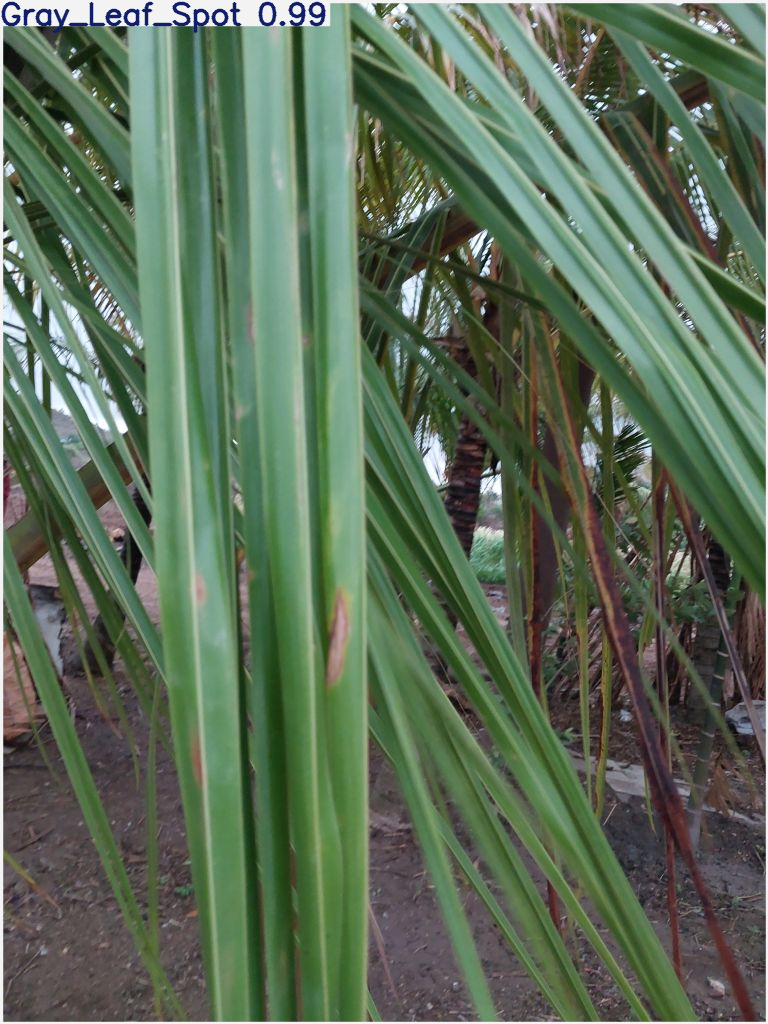

In [ ]:
from ultralytics import YOLO
from IPython.display import display, Image
import os

# Load your trained model
model = YOLO('/content/runs/detect/yolov11_coconut_disease/weights/best.pt')

# Path to a test image (you can choose any image from validation set)
test_img_path = '/content/yolo_dataset/images/val/Gray_Leaf_Spot_GrayLeafSpot235.jpg'  # Replace with actual image path

# Run inference
results = model(test_img_path)

# Show image with prediction
results[0].show()


In [ ]:
import torch
import torch.nn as nn
import math

class TTConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, tt_ranks=[1, 8, 8, 1], bias=True):
        super(TTConv2d, self).__init__()

        # Reshape in/out channels into TT shapes (example: 8×8 = 64)
        self.in_shape = [int(math.sqrt(in_channels)), int(math.sqrt(in_channels))]
        self.out_shape = [int(math.sqrt(out_channels)), int(math.sqrt(out_channels))]

        assert math.prod(self.in_shape) == in_channels
        assert math.prod(self.out_shape) == out_channels

        self.kernel_size = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        self.tt_ranks = tt_ranks

        # TT core weights
        self.cores = nn.ParameterList()
        for i in range(len(self.in_shape)):
            core = nn.Parameter(torch.randn(
                tt_ranks[i], self.out_shape[i], self.in_shape[i], tt_ranks[i+1]
            ))
            nn.init.xavier_uniform_(core)
            self.cores.append(core)

        # Bias
        self.bias = nn.Parameter(torch.zeros(out_channels)) if bias else None

        # 2D convolution layer applied after TT-decomposition
        self.depthwise_conv = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=self.kernel_size,
            padding=self.kernel_size[0] // 2,
            groups=1,
            bias=False
        )

    def forward(self, x):
        # Reconstruct full weight tensor from TT cores
        weight = self.tt_to_tensor()
        weight = weight.view(self.depthwise_conv.weight.shape)
        self.depthwise_conv.weight = nn.Parameter(weight)
        x = self.depthwise_conv(x)
        if self.bias is not None:
            x = x + self.bias.view(1, -1, 1, 1)
        return x

    def tt_to_tensor(self):
        # Reconstruct full tensor from TT-cores
        core = self.cores[0]
        res = core.permute(1, 2, 0, 3).contiguous().view(self.out_shape[0]*self.in_shape[0], -1)
        for i in range(1, len(self.in_shape)):
            core = self.cores[i]
            core = core.permute(1, 2, 0, 3).contiguous().view(self.out_shape[i]*self.in_shape[i], -1)
            res = torch.matmul(res, core)
        return res.T.view(self.out_shape[0]*self.out_shape[1], self.in_shape[0]*self.in_shape[1], 1, 1)


In [ ]:
from ultralytics import YOLO
import torch.nn as nn

# Load the pretrained YOLOv11n model
model = YOLO('yolo11n.pt')

# Get the model structure
model_model = model.model  # Access the full torch model

# 🔁 Replace specific Conv2d layers with TTConv2d
replace_count = 0
for name, module in model_model.named_modules():
    if isinstance(module, nn.Conv2d) and module.kernel_size == (3, 3):
        in_ch, out_ch = module.in_channels, module.out_channels

        try:
            # Try making TTConv2d with same in/out channels
            tt_layer = TTConv2d(in_channels=in_ch, out_channels=out_ch, kernel_size=3)

            # Traverse parent module and replace layer
            parent = model_model
            *path, last = name.split(".")
            for p in path:
                parent = getattr(parent, p)

            setattr(parent, last, tt_layer)
            replace_count += 1

            if replace_count >= 5:  # Replace only 5 for now to avoid overcompression
                break
        except:
            continue

print(f"✅ Replaced {replace_count} Conv2d layers with TTConv2d.")


✅ Replaced 5 Conv2d layers with TTConv2d.


In [ ]:
# Train the hybrid YOLOv11_TensorNet model
model.train(
    data="/content/yolo_dataset/data.yaml",  # Uses our coconut dataset
    epochs=10,                                # You can later try 30+ epochs for better accuracy
    imgsz=640,                                # Input image size
    batch=16,                                 # Batch size
    name="yolov11_tensornet_coconut"
)


Ultralytics 8.3.169 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov11_tensornet_coconut, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True

train: Scanning /content/yolo_dataset/labels/train.cache... 4637 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4637/4637 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 764.8±800.6 MB/s, size: 175.4 KB)


val: Scanning /content/yolo_dataset/labels/val.cache... 1161 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1161/1161 [00:00<?, ?it/s]


...

                   all       1161       1161          1      0.994      0.995      0.995



10 epochs completed in 0.302 hours.
Optimizer stripped from runs/detect/yolov11_tensornet_coconut/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/yolov11_tensornet_coconut/weights/best.pt, 5.5MB

Validating runs/detect/yolov11_tensornet_coconut/weights/best.pt...
Ultralytics 8.3.169 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,583,127 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 37/37 [00:14<00:00,  2.52it/s]


                   all       1161       1161          1      0.994      0.995      0.995
     Bud_Root_Dropping        103        103      0.999          1      0.995      0.995
               Bud_Rot         94         94      0.999          1      0.995      0.995
        Gray_Leaf_Spot        427        427          1      0.984      0.995      0.995
              Leaf_Rot        335        335          1      0.985      0.995      0.995
         Stem_Bleeding        202        202      0.999          1      0.995      0.995
Speed: 0.2ms preprocess, 2.4ms inference, 0.0ms loss, 3.4ms postprocess per image
Results saved to runs/detect/yolov11_tensornet_coconut


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x794b7daa6410>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [ ]:
!ls /content/runs/detect/yolov11_tensornet_coconut/weights


best.pt  last.pt


Saving LeafRot245.jpg to LeafRot245.jpg

image 1/1 /content/LeafRot245.jpg: 640x480 1 Leaf_Rot, 15.7ms
Speed: 7.9ms preprocess, 15.7ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 480)
Results saved to runs/detect/predict8


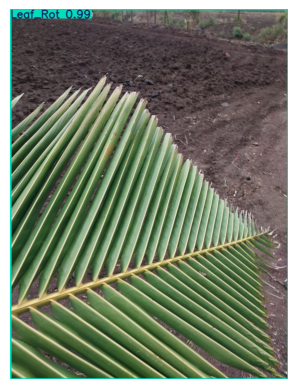

In [ ]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import os

# Load the model
model = YOLO("/content/runs/detect/yolov11_tensornet_coconut/weights/best.pt")

# Upload an image
from google.colab import files
uploaded = files.upload()

# Get image path
img_path = next(iter(uploaded))

# Run prediction and save result
results = model.predict(source=img_path, save=True)

# 📍 Get the path to the saved result image
result_img_path = os.path.join(results[0].save_dir, os.path.basename(img_path))

# Show the image
img = Image.open(result_img_path)
plt.imshow(img)
plt.axis('off')
plt.show()


In [ ]:
from google.colab import files

model_path = "/content/runs/detect/yolov11_tensornet_coconut/weights/best.pt"
files.download(model_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


image 1/1 /content/LeafRot026.jpg: 640x480 1 Leaf_Rot, 11.2ms
Speed: 3.2ms preprocess, 11.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)


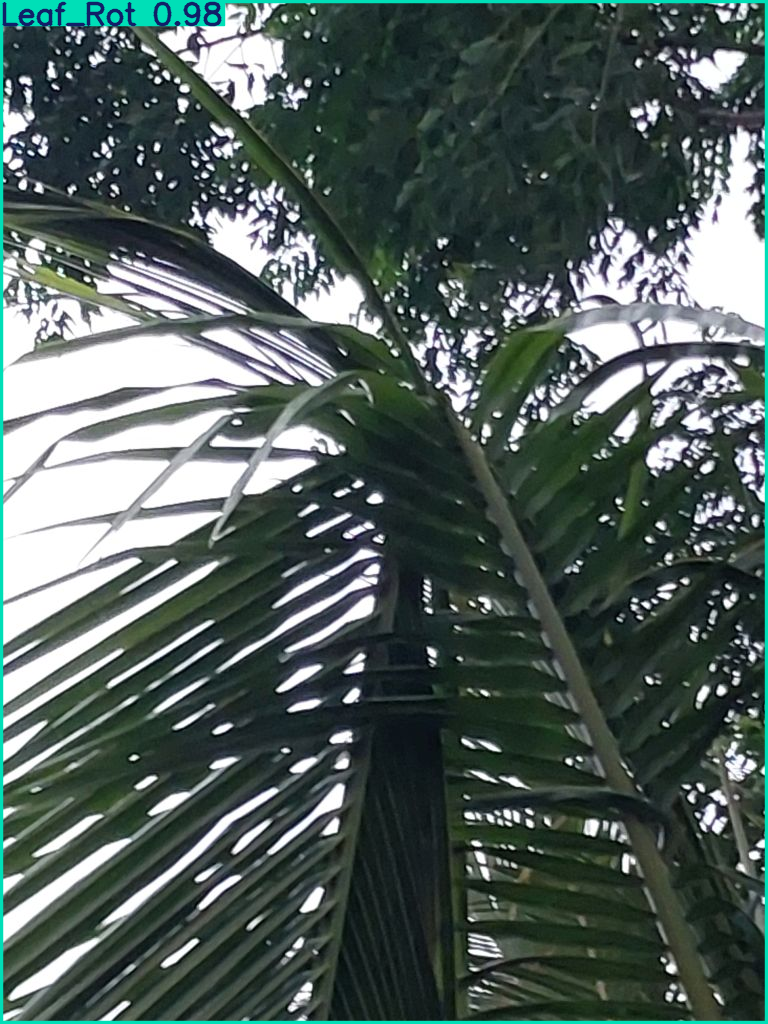

In [ ]:
from ultralytics import YOLO

# 🔁 Step 1: Load your trained model
model = YOLO('/content/best.pt')

# ✅ Step 2: Run inference on a new image
results = model('/content/LeafRot026.jpg')  # Replace with any new image path

# ✅ Step 3: Display results
results[0].show()  # Show annotated image
